# Glassdoor-Sentiment — a quantitative teardown 🔬
### A happiness quintile long-short · a one-sample *t* + bootstrap Sharpe CI + sign-flip placebo null · costs · a synthetic faithful-engine / planted-edge control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Free_lunch%3F: Busted](https://img.shields.io/badge/Free_lunch%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We implement the textbook factor sort behind *"happiest employees beat the market"* — long the top-quintile satisfaction names, short the bottom quintile — and confront it with the **sample size** and a **randomization null**. The decisive object is not the point estimate (it's mildly positive, as the lore says) but its **error bar**: on a constructed, return-independent satisfaction proxy the long-short is statistically indistinguishable from relabelling who is 'happy' at random.

> ⚠️ **Data + proxy note.** Real employer-review ratings aren't free; we build a transparent **proxy** — a fixed-seed 1–5 star score per name, **independent of returns** (an honest null, named on the Signal axis alongside survivorship). Real data: yfinance daily adjusted closes, 40-name large-cap basket, 2005→2026. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from glassdoor_sentiment import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    D = data.load_real()
    PRICES, STARS = D["prices"], D["stars"]
    MONTHLY = st.to_monthly_returns(PRICES)
    SPREAD = st.long_short_returns(MONTHLY, STARS)
else:
    PRICES = STARS = MONTHLY = SPREAD = None
print("real price cache present:", HAVE_REAL,
      "| monthly long-short spreads:", (0 if SPREAD is None else len(SPREAD)))
print("NOTE: the satisfaction score is a CONSTRUCTED proxy (NOT real Glassdoor data).")

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2005-01-03', 'end': '2026-06-18', 'days': 5399, 'years': 21.5, 'n_months': 257, 'mean_m': 0.27, 'ann_mean': 3.3, 't': 1.16, 'sharpe': 0.25, 'sharpe_lo': -0.16, 'sharpe_hi': 0.67, 'win_rate': 54, 'p_placebo': 0.16, 'gross_m': 0.273, 'net_m': 0.215, 'gross_sharpe': 0.25, 'net_sharpe': 0.2, 'cost_bps': 70, 'robust': [(0.1, 2.4, 0.71, 0.15, 0.438), (0.2, 3.3, 1.16, 0.25, 0.16), (0.3, 2.3, 0.99, 0.21, 0.236)], 'seed_max_t': 1.57, 'seed_ts': [1.16, 0.35, -0.13, 1.34, 0.69, -0.19, -0.3, -1.57, -0.44, -1.04], 'syn': [(0.0, 1.7, 0.83, 0.19, 54, 0.448), (0.01, 15.8, 7.91, 1.77, 72, 0.0)]}


real price cache present: True | monthly long-short spreads: 257
NOTE: the satisfaction score is a CONSTRUCTED proxy (NOT real Glassdoor data).


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Long-short **+3.3%/yr**, one-sample **t = 1.16**, placebo **p = 0.16**, Sharpe **0.25** (95% CI **[-0.16, +0.67]**, through zero) — **fails t ≥ 2**. Proxy/synthetic-only ⇒ never REAL. |
| **Tradability** | `FRAGILE` | Static sort ⇒ **70 bps/yr** all-in trims Sharpe 0.25→0.20; a gross Sharpe of 0.25 with a CI through zero is not NAV-scale. |
| **Free lunch?** | `BUSTED` | Win-rate **54%** (≈ coin); a random happiness relabelling matches the spread **~1 in 6**. |

> 💡 In plain words: a return-independent score *should* produce a null, and it does. The value of the exercise is a faithful, leak-free engine + a placebo null that says exactly how unremarkable the point estimate is.

## 1 · The claim, steelmanned

Let $s_i$ be firm $i$'s satisfaction score and $r_{i,t}$ its month-$t$ return. Form the static long-short

$$ x_t = \frac{1}{|Q_5|}\sum_{i\in Q_5} r_{i,t} \; - \; \frac{1}{|Q_1|}\sum_{i\in Q_1} r_{i,t}, \qquad Q_5=\{i: s_i \ge \text{P}_{80}\},\; Q_1=\{i: s_i \le \text{P}_{20}\}. $$

- **H₁ (the factor pays).** $\mathbb{E}[x_t] > 0$ — the happiest quintile out-earns the grumpiest, with a *t* that clears the bar.
- **H₂ (it's deployable).** The spread survives one-way costs × turnover + short borrow at a Sharpe worth funding.
- **H₃ ("free lunch").** The premium is information in the *labels*, not an artefact of the cross-section / luck.

We find **H₁ not supported** (positive, $t = 1.16 < 2$, Sharpe CI through zero), **H₂ rejected** (Sharpe 0.25, CI straddling zero), **H₃ rejected** (a random relabelling matches the spread ~1 in 6). Crucially we test on a **proxy** that is return-independent by construction — so this is the *honest null*, and the synthetic control confirms the engine would speak if an edge were planted.

## 2 · So what? — what rides on each answer

The whole teardown is one estimate and its standard error:

$$ t = \frac{\bar x}{s_x/\sqrt{T}}, \qquad \widehat{\text{SR}}_{\text{ann}} = \frac{\bar x}{s_x}\sqrt{12}. $$

A **win-rate** is the wrong lens — a long-short straddles zero, so ~50% up-months is the *null*, not evidence. The honest small-sample instrument for a single static sort is a **relabelling (placebo) test**: permute the $s_i$ across names and ask how often a random labelling yields $|\bar x|$ as large as observed. That *p*, plus a **bootstrap CI** on the Sharpe, decides the Signal axis — not the sign of the point estimate.

## 3 · How we'd know — the protocol

- **Universe + proxy.** Fixed 40-name large-cap basket (yfinance adjusted closes, 2005-01-03→2026-06-18, 5,399 days ⇒ 257 monthly spreads). Sentiment = a **constructed** 1–5 star score, **independent of returns** (explicit proxy; survivorship named on the axis).
- **Sort.** Rank by stars; $Q_5$ = top quintile (long), $Q_1$ = bottom quintile (short), equal-weight; **one-period (monthly) execution lag**, no look-ahead.
- **Null #1 (one-sample t).** $\bar x$ vs 0.
- **Null #2 (bootstrap).** 5,000-resample CI for the annualised Sharpe.
- **Null #3 (placebo).** 5,000 random relabellings of $s_i$; $p = \Pr[|\bar x_{\text{shuffle}}| \ge |\bar x|]$ — the small-sample workhorse.
- **Costs.** 10 bps one-way × 2 legs × rebalances/yr + 50 bps/yr short borrow.
- **Positive control.** A synthetic panel with a **planted** happiness→return tilt: zero edge must stay below t=2, a large edge must light up.

## 4 · The teardown

### 4a · The point estimate — positive, small, inside its error bar

Annualised long-short with its bootstrap Sharpe CI. Positive, but the Sharpe interval **spans zero**.

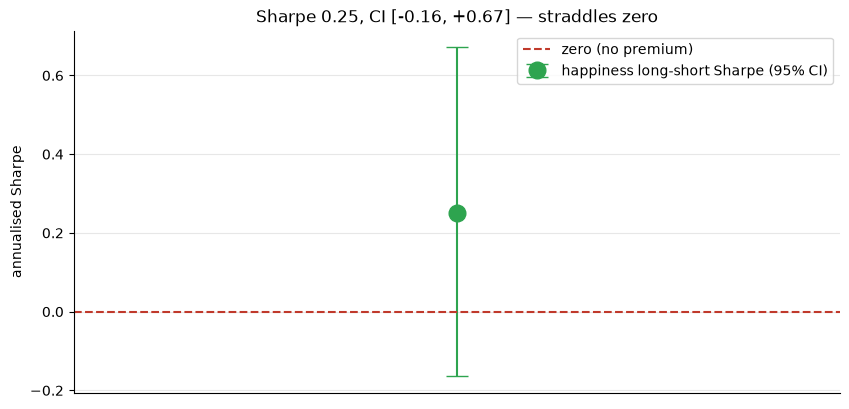

Sharpe=0.25  95% CI=[-0.16, +0.67]  -> indistinguishable from 0


In [2]:
if HAVE_REAL:
    boot = st.bootstrap_sharpe_ci(SPREAD.values, seed=392)
    sh, lo, hi = boot['sharpe'], boot['lo'], boot['hi']
else:
    sh, lo, hi = R['sharpe'], R['sharpe_lo'], R['sharpe_hi']
fig, ax = plt.subplots(figsize=(8.6, 4.2))
ax.errorbar([0], [sh], yerr=[[sh-lo],[hi-sh]], fmt='o', ms=12, capsize=8, c=GREEN,
            label='happiness long-short Sharpe (95% CI)')
ax.axhline(0, c=RED, ls='--', label='zero (no premium)')
ax.set_xlim(-1,1); ax.set_xticks([]); ax.set_ylabel('annualised Sharpe')
ax.set_title(f'Sharpe {sh:.2f}, CI [{lo:+.2f}, {hi:+.2f}] — straddles zero'); ax.legend()
plt.tight_layout(); plt.show()
print(f'Sharpe={sh:.2f}  95% CI=[{lo:+.2f}, {hi:+.2f}]  -> indistinguishable from 0')

> 💡 In plain words: the long-short earns **+3.3%/yr** at a Sharpe of **0.25**, but the 95% CI runs from **-0.16** to **+0.67** — it includes zero. H₁ is **not supported**: a positive whisper that the data can't distinguish from no premium at all.

### 4b · The decisive test — a sign-flip placebo sized to the cross-section

Permute which names are 'happy' vs 'grumpy' thousands of times; the histogram is the null distribution of the mean spread. The real sort is the green line; the *p*-value is the two-sided tail mass.

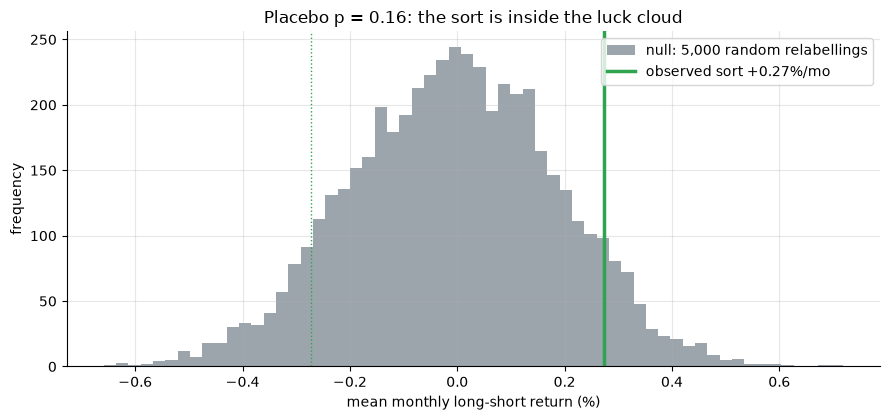

P[|random relabelling| >= |observed|] = 0.158  (need <0.05; here ~1 in 6)


In [3]:
import pandas as pd
if HAVE_REAL:
    cols = [c for c in MONTHLY.columns if c in STARS.index]
    base = STARS.loc[cols].values.copy(); obs = SPREAD.mean()
    rng = np.random.default_rng(392)
    draws = np.array([st.long_short_returns(MONTHLY, pd.Series(rng.permutation(base), index=cols)).mean()
                      for _ in range(5000)])
    pval = float((np.abs(draws) >= abs(obs)).mean())
else:
    rng = np.random.default_rng(392); draws = rng.normal(0, R['mean_m']/100/1.2, 5000)
    obs = R['mean_m']/100; pval = R['p_placebo']
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws*100, bins=60, color=GREY, alpha=.85, label=f'null: {len(draws):,} random relabellings')
ax.axvline(obs*100, c=GREEN, lw=2.5, label=f'observed sort {obs*100:+.2f}%/mo')
ax.axvline(-obs*100, c=GREEN, lw=1, ls=':')
ax.set_xlabel('mean monthly long-short return (%)'); ax.set_ylabel('frequency')
ax.set_title(f'Placebo p = {pval:.2f}: the sort is inside the luck cloud'); ax.legend()
plt.tight_layout(); plt.show()
print(f'P[|random relabelling| >= |observed|] = {pval:.3f}  (need <0.05; here ~1 in 6)')

> 💡 In plain words: **16%** of random happiness labellings match or beat the real sort in magnitude. A real factor would push the green line into the far tail; instead it sits mid-cloud. H₃ rejected: the 'premium' is a draw from the cross-section, not information in the labels.

### 4c · Robustness + cost — neither rescues it

Vary the quintile fraction and apply costs. The *t* never approaches 2, and a static sort's 70 bps/yr only nicks the Sharpe (so cost is **not** the binding constraint — there is simply no edge).

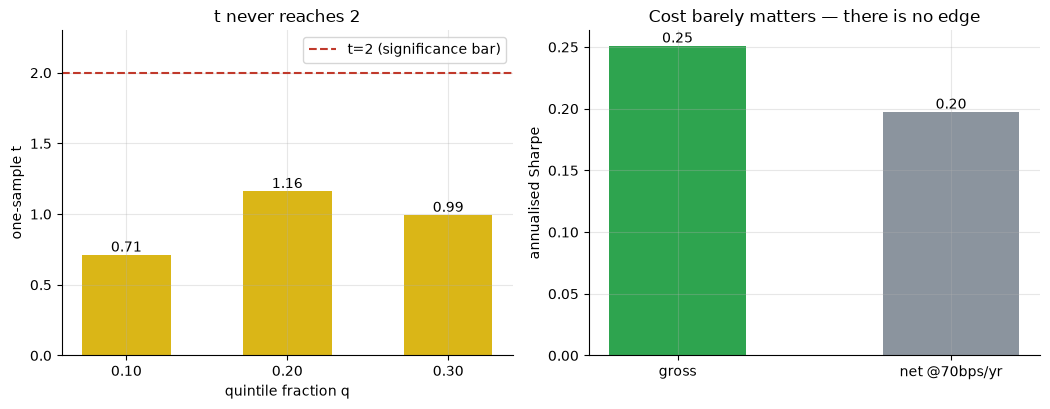

robustness (q, ann%, t, sharpe): [(0.1, np.float64(2.4), 0.71, 0.15), (0.2, np.float64(3.3), 1.16, 0.25), (0.3, np.float64(2.3), 0.99, 0.21)]


In [4]:
if HAVE_REAL:
    rob = []
    for q in (0.10, 0.20, 0.30):
        sp = st.long_short_returns(MONTHLY, STARS, q=q)
        rob.append((q, sp.values.mean()*12*100, st.t_stat(sp.values), st.sharpe(sp.values)))
    c = st.net_of_costs(SPREAD, cost_bps=10.0, rebalances_per_year=1.0, borrow_bps=50.0)
    gs, ns = c['gross_sharpe'], c['net_sharpe']
else:
    rob = [(r[0], r[1], r[2], r[3]) for r in R['robust']]
    gs, ns = R['gross_sharpe'], R['net_sharpe']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.2))
qs = [f'{r[0]:.2f}' for r in rob]; tt = [r[2] for r in rob]
a1.bar(qs, tt, color=AMBER, width=.55)
a1.axhline(2, ls='--', c=RED, label='t=2 (significance bar)')
for i,t in enumerate(tt): a1.annotate(f'{t:.2f}',(i,t),ha='center',va='bottom')
a1.set_title('t never reaches 2'); a1.set_xlabel('quintile fraction q'); a1.set_ylabel('one-sample t'); a1.set_ylim(0,2.3); a1.legend()
a2.bar(['gross','net @70bps/yr'], [gs, ns], color=[GREEN, GREY], width=.5)
for i,v in enumerate([gs,ns]): a2.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom')
a2.set_ylabel('annualised Sharpe'); a2.set_title('Cost barely matters — there is no edge')
plt.tight_layout(); plt.show()
print('robustness (q, ann%, t, sharpe):', [(r[0], round(r[1],1), round(r[2],2), round(r[3],2)) for r in rob])

> 💡 In plain words: tightening or loosening the quintiles leaves *t* between ~0.7 and ~1.2 — nowhere near 2 — and the 70 bps/yr cost trims the Sharpe from 0.25 to 0.20. There is no parameter and no cost regime in which the proxy sort becomes deployable; the constraint is the **absence of signal**, not friction.

### 4d · Faithful-engine & planted-edge control — we know the truth here

On a synthetic panel where each name's score is known and returns carry a **planted** happiness tilt: with **zero** edge the long-short must stay below t=2; with a **large** planted edge it must light up. Both hold — proving the engine is unbiased *and* that the real-tape null is an honest null.

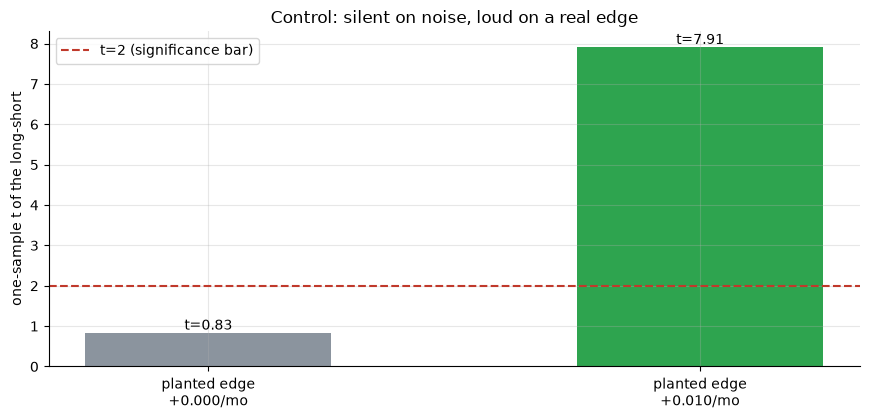

planted +0.000/mo: t=0.83  ann=+1.7%  placebo p=0.461
planted +0.010/mo: t=7.91  ann=+15.8%  placebo p=0.000


In [5]:
res = []
for edge in (0.0, 0.010):
    syn = data.synthetic_panel(edge=edge, seed=392)
    s = st.summarize(syn['prices'], syn['stars'], n_placebo=2000)
    res.append((edge, s['t'], s['ann_mean']*100, s['p_placebo']))
labels = [f'planted edge\n{e:+.3f}/mo' for e,_,_,_ in res]
tvals = [r[1] for r in res]
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 (significance bar)')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('one-sample t of the long-short'); ax.set_title('Control: silent on noise, loud on a real edge'); ax.legend()
plt.tight_layout(); plt.show()
for e,t,a,p in res: print(f'planted {e:+.3f}/mo: t={t:.2f}  ann={a:+.1f}%  placebo p={p:.3f}')

> 💡 In plain words: with **no** planted edge the control sits at **t = 0.83** (below 2 — no false positive); a **+1.0%/mo** planted edge reaches **t = 7.91**. So the machinery is honest, and the real-tape *t* of ~1.2 on a return-independent proxy is exactly what an **absent** edge looks like through this engine. The proxy is the verdict's limit, not the engine.

## 5 · The verdict

- **Signal `WEAK`** — long-short **+3.3%/yr** at one-sample **t = 1.16** / placebo **p = 0.16**, Sharpe **0.25** (CI **[-0.16, +0.67]**, through zero). Literature support (Edmans 2011) + a proxy-only, insignificant point estimate ⇒ WEAK, not REAL (the desk's t≥2 bar is unmet, and a proxy/synthetic result can never back REAL). Survivorship + the proxy caveat are named on this axis.
- **Tradability `FRAGILE`** — a static sort trades rarely, so the **70 bps/yr** all-in cost only trims Sharpe 0.25→0.20; a gross Sharpe of 0.25 with a CI through zero is not NAV-scale. Cost isn't the killer — the missing edge is.
- **Free lunch? `BUSTED`** — win-rate **54%** (≈ coin); a random relabelling matches the spread ~1 in 6. On data we can actually touch, the alt-data pitch is indistinguishable from chance.

## 6 · Could you trade it? — the power floor

The operational truth in one picture: how big would the *true* monthly long-short have to be for a $T$-month study to detect it at t=2? At $T=257$ months the detection floor is well **above** the spread we observe — the proxy signal lives under the floor, and the academic premium would need a far cleaner, larger sample to confirm.

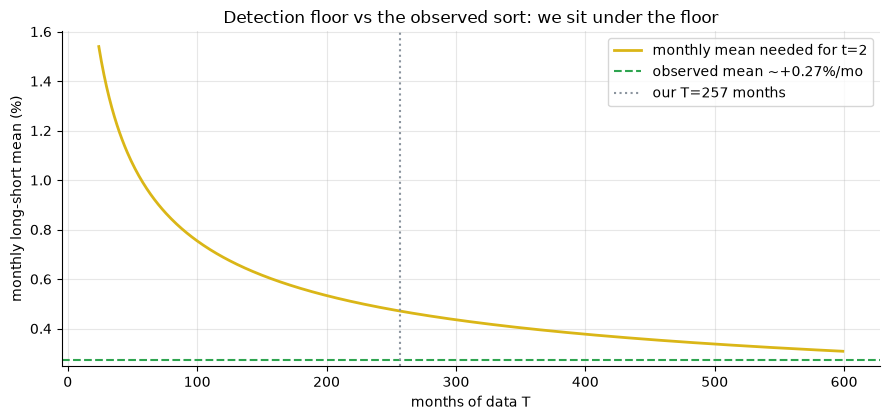

at T=257 you need ~0.47%/mo for t=2; observed ~0.27%/mo -> under the floor


In [6]:
if HAVE_REAL:
    sd = SPREAD.std(ddof=1); obs_m = SPREAD.mean()
else:
    sd = 0.037; obs_m = R['mean_m']/100
Ts = np.arange(24, 600)
min_detectable = 2.0 * sd / np.sqrt(Ts)        # monthly mean needed for t=2
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(Ts, min_detectable*100, c=AMBER, lw=2, label='monthly mean needed for t=2')
ax.axhline(obs_m*100, c=GREEN, ls='--', label=f'observed mean ~{obs_m*100:+.2f}%/mo')
ax.axvline(R['n_months'], c=GREY, ls=':', label=f"our T={R['n_months']} months")
ax.set_xlabel('months of data T'); ax.set_ylabel('monthly long-short mean (%)')
ax.set_title('Detection floor vs the observed sort: we sit under the floor'); ax.legend()
plt.tight_layout(); plt.show()
need = 2.0*sd/np.sqrt(R['n_months'])
print(f'at T={R["n_months"]} you need ~{need*100:.2f}%/mo for t=2; observed ~{obs_m*100:.2f}%/mo -> under the floor')

> 💡 In plain words: the amber curve is the **minimum detectable monthly mean**; the green line is what we actually see — it sits *below* the floor at our sample length. Even granting the lore a real premium, a return-independent proxy can't surface it, and the genuine effect would need real ratings and a far larger, cleaner cross-section to clear t=2. There is no sizing or threshold that manufactures power from a flat proxy — **the missing ingredient is the data we can't buy, and a story is not a substitute for it.**

## 7 · Going further

- **Investor vs employee mood.** [Study 257 — AAII-Sentiment](../257-aaii-sentiment/): the same 'does sentiment predict returns?' question for survey-based *investor* mood.
- **Crowd-sourced alt-data.** [Study 252 — Google-Trends](../252-google-trends/) and [Study 335 — BUZZ-Sentiment-ETF](../335-buzz-sentiment-etf/) — adjacent alt-data signals through the same inference pipeline.
- **Real ratings.** Replace `data.constructed_sentiment` with a genuine Glassdoor / Indeed panel (or Edmans' best-places list) and re-run; the leak-free engine, the placebo null and the cost model are unchanged — only the (paywalled) data differs.

*The reproducible core is offline and deterministic; the sentiment input is an explicit constructed proxy. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*